# 🎬 Movie Review Sentiment Analysis

## 📌 Problem Statement
Build a machine learning model to classify movie reviews as Positive or Negative using NLP.

## 🎯 Objectives
- Sentiment Analysis
- Text preprocessing
- TF-IDF vectorization
- Logistic Regression
- Model evaluation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import movie_reviews
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from wordcloud import WordCloud

plt.style.use('ggplot')

In [2]:
nltk.download('movie_reviews')
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package movie_reviews to
[nltk_data]     C:\Users\SivaGuduri\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\movie_reviews.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\SivaGuduri\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\SivaGuduri\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
documents = []

for category in movie_reviews.categories():
    for fileid in movie_reviews.fileids(category):
        review = movie_reviews.raw(fileid)
        documents.append((review, category))

df = pd.DataFrame(documents, columns=['review', 'sentiment'])

df.head()

,review,sentiment
0,"plot : two teen couples go to a church party ,...",neg
1,the happy bastard's quick movie review \ndamn ...,neg
2,it is movies like these that make a jaded movi...,neg
3,""" quest for camelot "" is warner bros . ' firs...",neg
4,synopsis : a mentally unstable man undergoing ...,neg


In [4]:
df.shape

(2000, 2)

In [5]:
df['sentiment'].value_counts()

sentiment
neg    1000
pos    1000
Name: count, dtype: int64

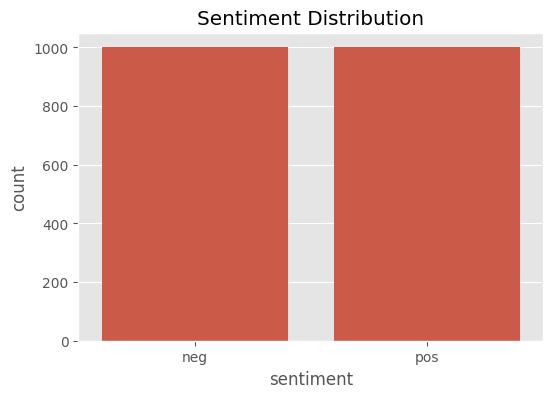

In [6]:
plt.figure(figsize=(6,4))
sns.countplot(x='sentiment', data=df)
plt.title('Sentiment Distribution')
plt.show()

In [7]:
df['review_length'] = df['review'].apply(len)
df.head()

,review,sentiment,review_length
0,"plot : two teen couples go to a church party ,...",neg,4043
1,the happy bastard's quick movie review \ndamn ...,neg,1370
2,it is movies like these that make a jaded movi...,neg,2848
3,""" quest for camelot "" is warner bros . ' firs...",neg,2929
4,synopsis : a mentally unstable man undergoing ...,neg,4418


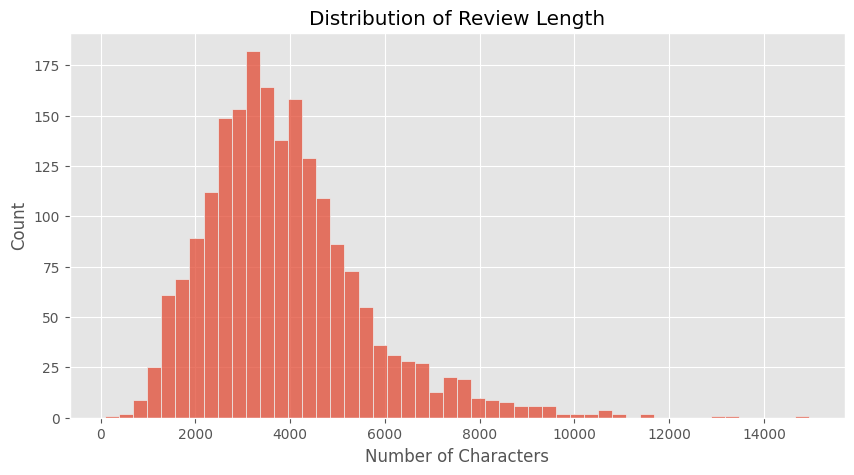

In [8]:
plt.figure(figsize=(10,5))
sns.histplot(df['review_length'], bins=50)
plt.title('Distribution of Review Length')
plt.xlabel('Number of Characters')
plt.show()

## 🧹 Text Preprocessing
Cleaning text by:
- converting to lowercase
- removing punctuation
- removing stopwords
- tokenizing text

In [9]:
import string

stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()
    
    tokens = word_tokenize(text)
    
    cleaned_tokens = [
        word for word in tokens
        if word.isalpha() and word not in stop_words
    ]
    
    return " ".join(cleaned_tokens)

In [10]:
df['clean_review'] = df['review'].apply(preprocess_text)

df[['review', 'clean_review']].head()

,review,clean_review
0,"plot : two teen couples go to a church party ,...",plot two teen couples go church party drink dr...
1,the happy bastard's quick movie review \ndamn ...,happy bastard quick movie review damn bug got ...
2,it is movies like these that make a jaded movi...,movies like make jaded movie viewer thankful i...
3,""" quest for camelot "" is warner bros . ' firs...",quest camelot warner bros first attempt steal ...
4,synopsis : a mentally unstable man undergoing ...,synopsis mentally unstable man undergoing psyc...


## 🔢 TF-IDF Vectorization
Convert text into numerical features for machine learning.

In [11]:
tfidf = TfidfVectorizer(max_features=5000)

X = tfidf.fit_transform(df['clean_review'])
y = df['sentiment']

X.shape

(2000, 5000)

## Train/Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(1600, 5000)
(400, 5000)


## 🤖 Model Training
Training Logistic Regression classifier.

In [13]:
model = LogisticRegression()

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [14]:
y_pred = model.predict(X_test)

## Accuracy

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8275


## 📊 Model Evaluation
Evaluating model performance.

In [16]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         neg       0.83      0.82      0.83       199
         pos       0.83      0.83      0.83       201

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



## Confusion Matrix Heatmap

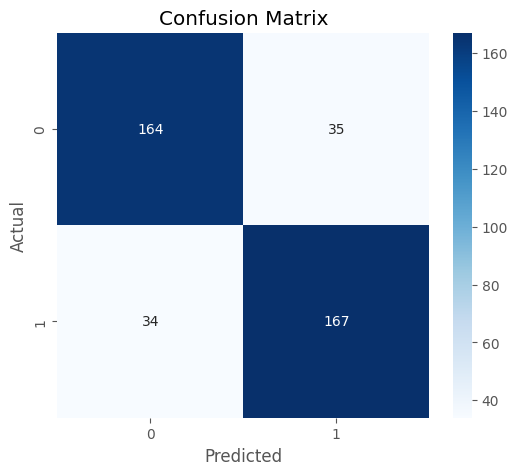

In [17]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## WordClouds (Positive reviews)

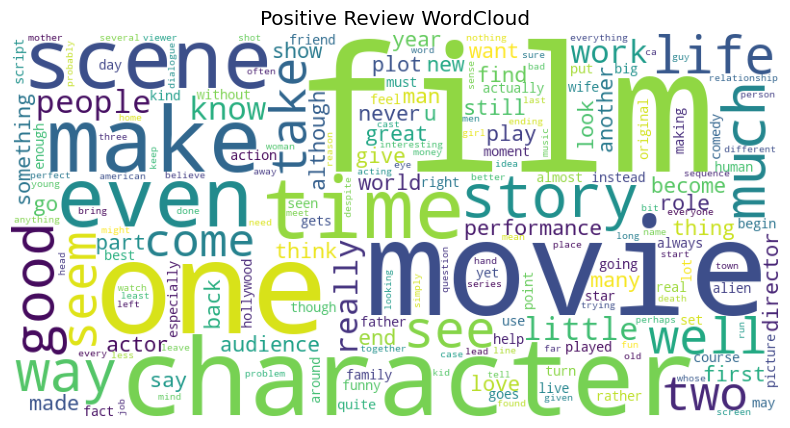

In [18]:
positive_text = " ".join(df[df['sentiment'] == 'pos']['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Positive Review WordCloud')
plt.show()

## WordClouds (Negative reviews)

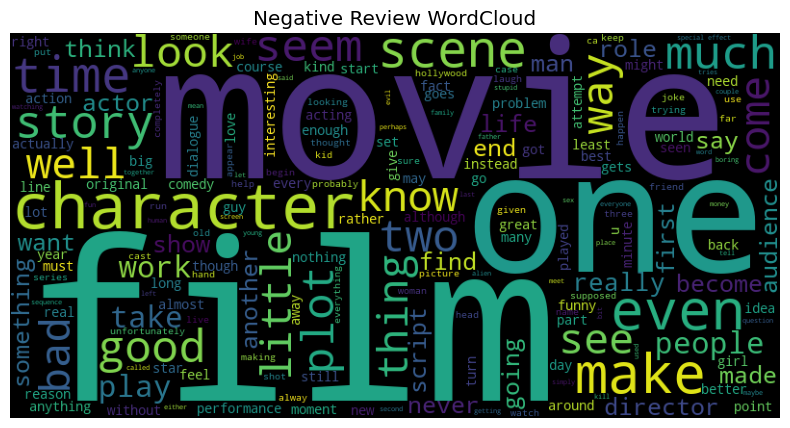

In [19]:
negative_text = " ".join(df[df['sentiment'] == 'neg']['clean_review'])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='black'
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis('off')
plt.title('Negative Review WordCloud')
plt.show()

## 🎯 Custom Prediction Demo
Test the model with your own movie reviews.

In [20]:
def predict_sentiment(review):
    cleaned = preprocess_text(review)
    vectorized = tfidf.transform([cleaned])
    prediction = model.predict(vectorized)[0]

    if prediction == 'pos':
        return "😊 Positive Review"
    else:
        return "😞 Negative Review"

In [21]:
predict_sentiment("This movie was absolutely amazing. Brilliant acting and wonderful story.")

'😊 Positive Review'

In [22]:
predict_sentiment("Worst movie ever. Waste of time. Terrible acting and boring plot.")

'😞 Negative Review'

In [23]:
predict_sentiment("The story was okay but the acting was terrible and too slow.")

'😞 Negative Review'

In [24]:
sample_reviews = [
    "This movie was fantastic! I loved every moment.",
    "Terrible movie. Complete waste of time.",
    "Average film, some good moments but overall boring."
]

for review in sample_reviews:
    print("Review:", review)
    print("Prediction:", predict_sentiment(review))
    print("-" * 60)

Review: This movie was fantastic! I loved every moment.
Prediction: 😊 Positive Review
------------------------------------------------------------
Review: Terrible movie. Complete waste of time.
Prediction: 😞 Negative Review
------------------------------------------------------------
Review: Average film, some good moments but overall boring.
Prediction: 😊 Positive Review
------------------------------------------------------------
